# Simulation Based Inference to Remove Sampling Bias - Designing Household Studies


Model  with parameters `beta`, `delta`, `mu_inf_SC`, `mu_inf_SA`, `mu_inf_AI`, `mu_inf_AC`, `mu_inf_AA`, `mu_susc_C`, `mu_susc_A`.
Neural networks trained with fewer households to see the impact of the number of households (this is done in the configurator).

Simulation study with different number of households and different maximal follow-up times (no new simulation required for that).

In [ ]:
import os
import pickle
from functools import partial
from itertools import product
from time import perf_counter

import bayesflow as bf
import numpy as np
import tensorflow as tf
from bayesflow.simulation import GenerativeModel, Prior, Simulator, ContextGenerator
from matplotlib import pyplot as plt
from tarp import get_tarp_coverage
from tqdm import tqdm

from network_config import load_model
from helper_functions import shorten_follow_up_time

In [ ]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
n_procs = int(os.environ.get('SLURM_CPUS_PER_TASK', 1))
batch_size = 128
iterations_per_epoch = 1000

In [ ]:
train_network = False
presimulate = False

## Define model and prior

We fix some parameters such that the model becomes identifiable. We fix the parameters `alpha`, `mu_protect_acq`, `mu_protect_transm`. We checked whether we need to fix  `delta` as well.

In [ ]:
fixed_parameters = {
    'alpha': {
        "alpha": 0.001,  # introduces too much variation in the data
        "mu_protect_acq": 0.8,  # not enough data to estimate
        "mu_protect_transm": 1.  # not enough data to estimate
    },
    'omicron': {
        "alpha": 0.002,  # introduces too much variation in the data
        "mu_protect_acq": 0.8,  # not enough data to estimate
        "mu_protect_transm": 0.8  # not enough data to estimate
    }
}

param_names = ['alpha', 'beta', 'delta',
               'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
               'mu_susc_C', 'mu_susc_A',
               'mu_protect_acq', 'mu_protect_transm']

# Drop param names that are in fixed_parameters['alpha']
param_names = [param for param in param_names if param not in fixed_parameters['alpha']]
mu_count = len([param for param in param_names if param.startswith('mu')])
n_params = len(param_names)
non_mu_count = n_params - mu_count

In [ ]:
# define the prior    
def prior(batch_size: int) -> np.ndarray:
    param_batch = np.zeros((batch_size, n_params))
    # alpha
    # param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
    # log(beta)
    param_batch[:, 0] = np.random.normal(0, 1, batch_size)
    # delta
    if 'delta' in param_names:
        param_batch[:, 1] = np.random.normal(0, 1, batch_size)
        #param_batch[:, 1] = np.random.uniform(-3, 3, batch_size)
    # log(mu_...)
    param_batch[:, non_mu_count:] = np.random.normal(0, 1, (batch_size, mu_count))
    return param_batch

# for normalization of the parameters
prior_mean = np.zeros(n_params)
prior_std = np.ones(n_params)

assert prior_mean.size == prior_std.size, 'Number of parameters do not match'
assert prior_mean.size == prior(1).shape[1], \
    'Number of parameters do not match in prior'

In [ ]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    def simulator(log_params: np.ndarray,
                  selection_procedure: str,
                  variant: str,
                  minimal_length: int,
                  fixed_parameters_dict: dict = None)  -> np.ndarray:
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')
else:
    from Simulator.simulator import simulator

# if name starts with mu, create log name
log_param_names = []
for p_name in param_names:
    if p_name == 'delta':
        log_param_names.append(p_name)
    else:
        log_param_names.append(f'log({p_name})')
    
assert n_params == prior_mean.size, 'Number of parameters in normalization do not match names'
print(f"Number of parameters: {n_params}")

In [ ]:
# plot prior
fix, ax = plt.subplots(1, len(log_param_names), figsize=(10, 3), sharey=True, tight_layout=True)
n_samples = 1000
prior_samples = prior(n_samples)
for i in range(len(log_param_names)):
    ax[i].hist(prior_samples[:, i], bins=20, density=True)
    ax[i].set_xlabel(log_param_names[i])
plt.show()

## Define the generative model for BayesFlow

In [ ]:
bayesflow_prior = Prior(
    batch_prior_fun=prior,
    param_names=log_param_names
)
gen = ContextGenerator(
    batchable_context_fun=lambda : np.random.choice(['pedcov', 'random']),
    non_batchable_context_fun=lambda : np.random.choice(['alpha', 'omicron'])
)
bayes_simulator = Simulator(
    simulator_fun=partial(simulator, n_households=10, fixed_parameters_dict=fixed_parameters),
    context_generator=gen
)
generative_model = GenerativeModel(
    prior=bayesflow_prior, 
    simulator=bayes_simulator,
    skip_test=True
)

## Generate training data

In [ ]:
presim_folder = 'presimulations_both_variants'

if presimulate:    
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    from time import sleep
    sleep(job_array_id)

    for job_1000 in range(10):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        epoch_id = (job_array_id+add_to_id) // iterations_per_epoch
        print(f'presimulating epoch {epoch_id} job {job_array_id+add_to_id}')
        os.makedirs(presim_folder, exist_ok=True)
        generative_model.presimulate_and_save(batch_size=batch_size, 
                                              folder_path=f'{presim_folder}/epoch_{epoch_id}',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    #exit()

In [ ]:
# generate validation data
sim_folder = 'sim_data'

valid_file_name = "valid_data_both_variants"

np.random.seed(42)
n_valid = 256
prior_draws = bayesflow_prior(n_valid // 4)
valid_data_dict = {}

for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):

    valid_file_name_vs = f"{valid_file_name}_{variant}_{selection}"
    if os.path.exists(f'{sim_folder}/{valid_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'rb') as f:
            valid_data_dict[f'{variant}_{selection}'] = pickle.load(f)
    else:
        print(f"Simulating validation data for {variant} with {selection}")
        new_valid_data = {
            'prior_draws': prior_draws['prior_draws'].copy(),
            'sim_batchable_context': np.array([[selection] for _ in range(n_valid // 4)]),
            'sim_non_batchable_context': np.array([[variant] for _ in range(n_valid // 4)]),
        }
        new_valid_data['sim_data'] = np.array([simulator(params,
                                                         selection_procedure=selection,
                                                         variant=variant,
                                                         fixed_parameters_dict=fixed_parameters)
                                               for params in new_valid_data['prior_draws']])
        # save the data
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_valid_data, f)
        valid_data_dict[f'{variant}_{selection}'] = new_valid_data

# we cannot use both variants at the same time for validation since not batchable
valid_data_alpha = {key: np.concatenate((valid_data_dict['alpha_pedcov'][key],
                                   valid_data_dict['alpha_random'][key])
                                  ) for key in valid_data_dict['alpha_pedcov'].keys()}
valid_data_omicron = {key: np.concatenate((valid_data_dict['omicron_pedcov'][key],
                                   valid_data_dict['omicron_random'][key])
                                  ) for key in valid_data_dict['omicron_pedcov'].keys()}

In [ ]:
def renormalize_params(params: np.ndarray, keep_log_transform: bool = False) -> np.ndarray:
    un_scaled_params = params.copy()
    un_scaled_params = un_scaled_params * prior_std + prior_mean
    
    if not keep_log_transform:
        for p_i in range(n_params):
            if log_param_names[p_i][:3] != 'log':
                continue
                
            if un_scaled_params.ndim == 2:
                un_scaled_params[:, p_i] = np.exp(un_scaled_params[:, p_i])
            elif un_scaled_params.ndim == 3:
                 un_scaled_params[:, :, p_i] = np.exp(un_scaled_params[:, :, p_i])
            else:
                raise ValueError('Invalid number of dimensions')
    return un_scaled_params

## Load neural network architectures

In [ ]:
# settings
net_id = 3  # 3 for both selection methods, 9 for only PedCov
amortizer_folder = 'results_designing'

trainer, amortizer_name = load_model(
    model_id=net_id,
    n_params=n_params,
    generative_model=generative_model,
    prior_mean=prior_mean,
    prior_std=prior_std,
    train_network=train_network,
    valid_data=valid_data_alpha,
    presim_folder=presim_folder,
    amortizer_folder=amortizer_folder,
    drop_n_households=True if train_network else False,  # to check SBC on full households
)

## Check the training convergence

In [ ]:
if 'delta' in param_names:
    results_folder = 'results_both_variants'
else:
    results_folder = 'results_both_variants_delta_fixed'
results_folder += '_design'
os.makedirs(results_folder, exist_ok=True)

In [ ]:
history = trainer.loss_history.get_plottable()
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [ ]:
test_sims_alpha = trainer.configurator(valid_data_alpha)
test_sims_omicron = trainer.configurator(valid_data_omicron)

In [ ]:
# we need to join samples from both variants to check SBC and other diagnostics
posterior_samples_alpha = trainer.amortizer.sample(test_sims_alpha, n_samples=100)
posterior_samples_omicron = trainer.amortizer.sample(test_sims_omicron, n_samples=100)
posterior_samples = np.concatenate((posterior_samples_alpha, posterior_samples_omicron), axis=0)
posterior_samples = renormalize_params(posterior_samples, keep_log_transform=True)

prior_draws_alpha = renormalize_params(test_sims_alpha["parameters"], keep_log_transform=True)
prior_draws_omicron = renormalize_params(test_sims_omicron["parameters"], keep_log_transform=True)
prior_draws = np.concatenate((prior_draws_alpha, prior_draws_omicron), axis=0)

In [ ]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=log_param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_sbc.png')

In [ ]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=log_param_names);

In [ ]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=log_param_names);

In [ ]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], posterior_samples.shape[0], posterior_samples.shape[2])
ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws, references='random', 
                                         metric='euclidean', norm=True, bootstrap=True)

In [ ]:
k_sigma = [1, 2, 3]

_, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

## Simulation Study

All parameters are set to 1 besides one parameter. Inference workflow applied on the full model still. Check if for the changing parameter the true parameter is still recovered.

Here we tell the network the right selection procedure. Results should be not be biased for no selection procedure. 

In [42]:
# generate simulation study or load data
simulation_study_file_name = "sim_study_data_both_variants"
n_sims_per_param = 50

np.random.seed(42)
prior_draws_sim_study = bayesflow_prior(n_sims_per_param)['prior_draws']
non_fix_indices_study = np.arange(n_params)
if 'delta' in param_names:
    fix_indices_study = np.array([param_names.index('beta'), param_names.index('delta')])
    non_fix_indices_study = np.delete(non_fix_indices_study, fix_indices_study)
    prior_draws_sim_study[:, fix_indices_study] = np.array([np.log(0.2), 1.3])
else:
    fix_indices_study = np.array([param_names.index('beta')])
    non_fix_indices_study = np.delete(non_fix_indices_study, fix_indices_study)
    prior_draws_sim_study[:, fix_indices_study] = np.array([np.log(0.2)])

    
sim_study_dict = {}
sim_study_bias_dict = {}

for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):
    
    study_file_name_vs = f"{simulation_study_file_name}_{variant}_{selection}"
    if os.path.exists(f'{sim_folder}/{study_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'rb') as f:
            sim_study_dict[f'{variant}_{selection}'] = pickle.load(f)
    else:
        print(f"Simulating simulation study for {variant} with {selection}")
        new_sim_data = {
            'prior_draws': np.zeros((len(non_fix_indices_study), n_sims_per_param, n_params)),  # all parameters are set to log(1)
            'sim_batchable_context': np.array([[[selection] for _ in range(n_sims_per_param)]
                                               for _ in range(len(non_fix_indices_study))]),
            'sim_non_batchable_context': np.array([[[variant] for _ in range(n_sims_per_param)]
                                                   for _ in range(len(non_fix_indices_study))]),
            'sim_data': np.empty((len(non_fix_indices_study), n_sims_per_param,
                                  valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[1],
                                  valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[2], 
                              valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[3])),
        }
        for i, index_i in enumerate(non_fix_indices_study):
            # set all except the i-th parameter to log(1)
            new_sim_data['prior_draws'][i, :, index_i] = prior_draws_sim_study.copy()[:, index_i]
            new_sim_data['prior_draws'][i, :, fix_indices_study] = prior_draws_sim_study.copy()[:, fix_indices_study].T  # fix params
            new_sim_data['sim_data'][i] = np.array([simulator(params,
                                                              selection_procedure=selection,
                                                              variant=variant,
                                                              fixed_parameters_dict=fixed_parameters)
                                                    for params in new_sim_data['prior_draws'][i]])
        # save the data
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_sim_data, f)
        sim_study_dict[f'{variant}_{selection}'] = new_sim_data

## Simulation Study with different number of households

In [43]:
# perform inference on simulation study while dropping different number of households (which is random)
results_sim_study_drop = {} 
n_samples_study = 1000  # increase for more accurate results, e.g. 1000 samples
drop_n_households_list = [0., 0.1, 0.3, 0.5, 0.7, 0.9]
selection_data, selection_inference = 'pedcov', 'pedcov'

for drop_n in tqdm(drop_n_households_list):
    trainer_drop_n, _ = load_model(
        model_id=net_id,
        n_params=n_params,
        generative_model=generative_model,
        prior_mean=prior_mean,
        prior_std=prior_std,
        train_network=train_network,
        valid_data=valid_data_alpha,
        presim_folder=presim_folder,
        amortizer_folder=amortizer_folder,
        amortizer_return_attention_weights=False,  # only needed for diagnostics of attention
        drop_n_households=drop_n
    )
    
    for variant in ['alpha', 'omicron']:
        # estimate median and CI for each parameter
        results_sim_study_vs = {
            'posterior_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'posterior_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
            'relative_bias_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'relative_bias_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
            'overall_median_error': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
        }
        for i, index_i in enumerate(non_fix_indices_study):
            # get data for this parameter
            sim_study_i = {
                'sim_data': sim_study_dict[f'{variant}_{selection_data}']['sim_data'][i],
                'prior_draws': sim_study_dict[f'{variant}_{selection_data}']['prior_draws'][i],
                # on purpose a different selection procedure than the data was generated with
                'sim_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_batchable_context'][i],
                'sim_non_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_non_batchable_context'][i]
            }
            simulation_study_data_conf = trainer_drop_n.configurator(sim_study_i)
            # get posterior samples
            posterior_samples_sim_study = (
                trainer_drop_n.amortizer.sample(simulation_study_data_conf, n_samples=n_samples_study)
            )
            posterior_samples_sim_study = renormalize_params(posterior_samples_sim_study, keep_log_transform=False)
            prior_draws_study = renormalize_params(simulation_study_data_conf['parameters'], keep_log_transform=False)

            # get median and CI for each parameter of posterior samples
            # we only care about the changing parameter, the others are set to 1
            results_sim_study_vs['posterior_median'][i] = np.median(posterior_samples_sim_study[:, :, index_i], axis=1)
            results_sim_study_vs['posterior_CI'][i] = np.quantile(posterior_samples_sim_study[:, :, index_i],
                                                                  [0.005, 0.025, 0.1,
                                                                   0.995, 0.975, 0.9],
                                                                  axis=1)
            # get median and CI for each parameter of relative bias (estimate - true) / true
            relative_bias = (posterior_samples_sim_study[:, :, index_i] - prior_draws_study[:, index_i][:, np.newaxis]) / prior_draws_study[:, index_i][:, np.newaxis]
            results_sim_study_vs['relative_bias_median'][i] = np.median(relative_bias, axis=1)
            results_sim_study_vs['relative_bias_CI'][i] = np.quantile(relative_bias,
                                                                      [0.005, 0.025, 0.1,
                                                                       0.995, 0.975, 0.9],
                                                                      axis=1)
            # order the relative bias by size of the true parameters
            ordering = np.argsort(sim_study_i['prior_draws'][:, index_i])
            results_sim_study_vs['relative_bias_median'][i] = results_sim_study_vs['relative_bias_median'][i][ordering]
            results_sim_study_vs['relative_bias_CI'][i] = results_sim_study_vs['relative_bias_CI'][i][:, ordering]

            # get overall median error
            results_sim_study_vs['overall_median_error'][i] = np.sum(
                (np.median(posterior_samples_sim_study, axis=1) - prior_draws_study)**2, axis=1
            )

        results_sim_study_drop[f'{variant}_{drop_n}'] = results_sim_study_vs
    del trainer_drop_n

  0%|          | 0/6 [00:00<?, ?it/s]

amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention


INFO:root:Loaded loss history from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/history_250.pkl.
INFO:root:Networks loaded from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/ckpt-250


Networks loaded from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/ckpt-246
Best validation loss: 3.332637310028076


 17%|█▋        | 1/6 [00:17<01:26, 17.29s/it]

...

INFO:root:Loaded loss history from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/history_250.pkl.
INFO:root:Networks loaded from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/ckpt-250


Networks loaded from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/ckpt-246
Best validation loss: 3.332637310028076


 83%|████████▎ | 5/6 [01:27<00:17, 17.42s/it]INFO:root:Loaded loss history from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/history_250.pkl.
INFO:root:Networks loaded from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/ckpt-250


amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention
Networks loaded from amortizer_n_households/amortizer-sampling-bias-both_variants-7-attention/ckpt-246
Best validation loss: 3.332637310028076


100%|██████████| 6/6 [01:43<00:00, 17.24s/it]


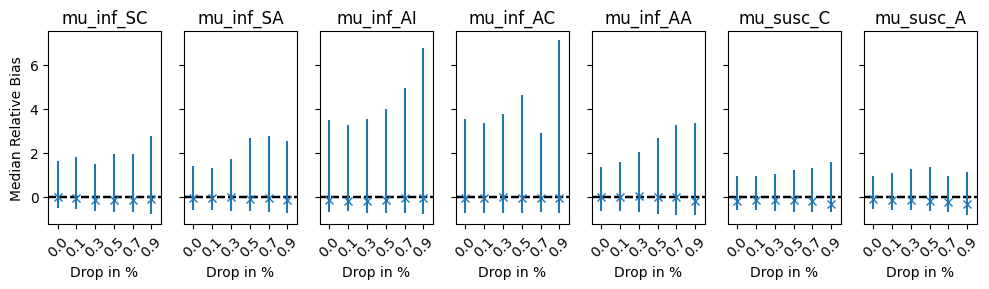

In [44]:
# plot bias in both scenarios
fig, ax = plt.subplots(1, len(non_fix_indices_study), sharex=True, sharey=True, figsize=(10, 3), tight_layout=True)
colors = ['#1f78b4']*len(non_fix_indices_study)  #['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c']

for j, drop_n in enumerate(drop_n_households_list):
    for i, index_i in enumerate(non_fix_indices_study):
        # plot a line around 0
        ax[i].axhline(0, color='black', ls='--', zorder=3)

        relative_alpha = results_sim_study_drop[f'alpha_{drop_n}']['relative_bias_median'][i]
        relative_omicron = results_sim_study_drop[f'omicron_{drop_n}']['relative_bias_median'][i]
        relative = np.concatenate((relative_alpha, relative_omicron))

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(relative, [0.025, 0.975])
        yerr = np.array([[np.median(relative) - lower_quantile],
                          [upper_quantile - np.median(relative)]])

        handle_alpha_mean = ax[i].errorbar(j,
                                           np.median(relative),
                                           yerr=yerr,
                                           color=colors[j], marker='x', label=r'Median Bias', zorder=4)
        ax[i].set_title(param_names[index_i])
        ax[i].set_xlim(-0.5, 5.5)
        ax[i].set_xticks(np.arange(len(drop_n_households_list)), labels=drop_n_households_list, rotation=45)
        ax[i].set_xlabel('Drop in %')
        ax[0].set_ylabel('Median Relative Bias')

fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_bias.png', bbox_inches='tight')
plt.show()

## Simulation Study with maximal Follow-Up Times

In [38]:
# perform inference on simulation study while setting different maximal follow-up times (networks not trained on this)
results_sim_study_followup = {} 
n_samples_study = 1000  # increase for more accurate results, e.g. 1000 samples
selection_data, selection_inference = 'pedcov', 'pedcov'
maximal_follow_ups = [20, 40, 60, 80, 100, 120, 140, 160]

for maximal_follow_up in tqdm(maximal_follow_ups):
    for variant in ['alpha', 'omicron']:
        # estimate median and CI for each parameter
        results_sim_study_vs = {
            'posterior_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'posterior_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
            'relative_bias_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'relative_bias_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
            'overall_median_error': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
        }
        for i, index_i in enumerate(non_fix_indices_study):
            # get data for this parameter
            sim_data_follow_up = shorten_follow_up_time(
                data=sim_study_dict[f'{variant}_{selection_data}']['sim_data'][i],
                max_followup=maximal_follow_up
            )
            sim_study_i = {
                'sim_data': sim_data_follow_up,
                'prior_draws': sim_study_dict[f'{variant}_{selection_data}']['prior_draws'][i],
                # on purpose a different selection procedure than the data was generated with
                'sim_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_batchable_context'][i],
                'sim_non_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_non_batchable_context'][i]
            }
            simulation_study_data_conf = trainer.configurator(sim_study_i)
            # get posterior samples
            posterior_samples_sim_study = (
                trainer.amortizer.sample(simulation_study_data_conf, n_samples=n_samples_study)
            )
            posterior_samples_sim_study = renormalize_params(posterior_samples_sim_study, keep_log_transform=False)
            prior_draws_study = renormalize_params(simulation_study_data_conf['parameters'], keep_log_transform=False)

            # get median and CI for each parameter of posterior samples
            # we only care about the changing parameter, the others are set to 1
            results_sim_study_vs['posterior_median'][i] = np.median(posterior_samples_sim_study[:, :, index_i], axis=1)
            results_sim_study_vs['posterior_CI'][i] = np.quantile(posterior_samples_sim_study[:, :, index_i],
                                                                  [0.005, 0.025, 0.1,
                                                                   0.995, 0.975, 0.9],
                                                                  axis=1)
            # get median and CI for each parameter of relative bias (estimate - true) / true
            relative_bias = (posterior_samples_sim_study[:, :, index_i] - prior_draws_study[:, index_i][:, np.newaxis]) / prior_draws_study[:, index_i][:, np.newaxis]
            results_sim_study_vs['relative_bias_median'][i] = np.median(relative_bias, axis=1)
            results_sim_study_vs['relative_bias_CI'][i] = np.quantile(relative_bias,
                                                                      [0.005, 0.025, 0.1,
                                                                       0.995, 0.975, 0.9],
                                                                      axis=1)
            # order the relative bias by size of the true parameters
            ordering = np.argsort(sim_study_i['prior_draws'][:, index_i])
            results_sim_study_vs['relative_bias_median'][i] = results_sim_study_vs['relative_bias_median'][i][ordering]
            results_sim_study_vs['relative_bias_CI'][i] = results_sim_study_vs['relative_bias_CI'][i][:, ordering]

            # get overall median error
            results_sim_study_vs['overall_median_error'][i] = np.sum(
                (np.median(posterior_samples_sim_study, axis=1) - prior_draws_study)**2, axis=1
            )

        results_sim_study_followup[f'{variant}_{maximal_follow_up}'] = results_sim_study_vs

100%|██████████| 8/8 [02:14<00:00, 16.83s/it]


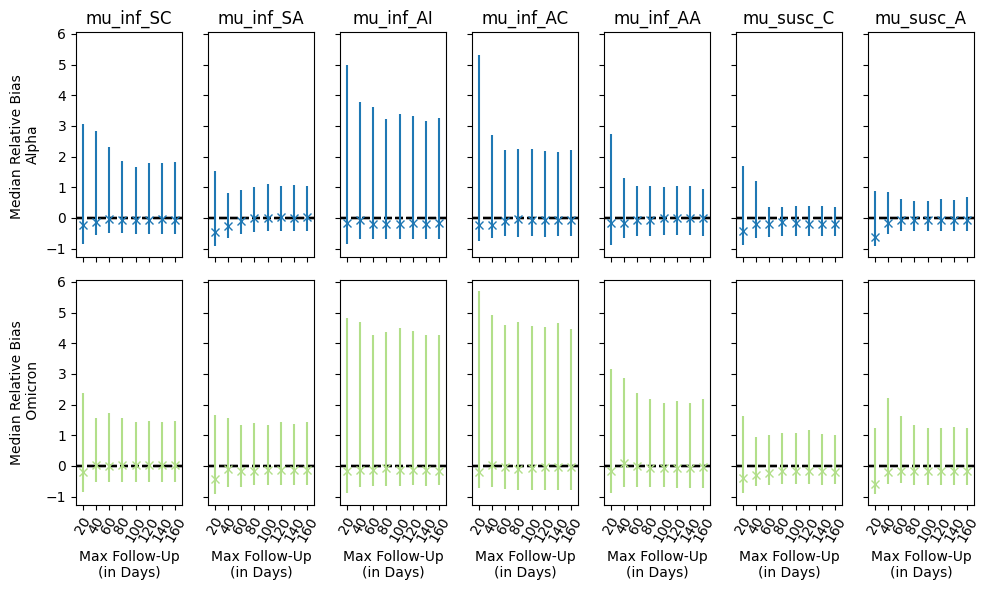

In [41]:
# plot bias in both scenarios
fig, ax = plt.subplots(2, len(non_fix_indices_study), sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
colors = ['#1f78b4', '#b2df8a']

for j, maximal_follow_up in enumerate(maximal_follow_ups):
    for i, index_i in enumerate(non_fix_indices_study):
        # plot a line around 0
        ax[0, i].axhline(0, color='black', ls='--', zorder=3)
        ax[1, i].axhline(0, color='black', ls='--', zorder=3)

        relative_alpha = results_sim_study_followup[f'alpha_{maximal_follow_up}']['relative_bias_median'][i]
        relative_omicron = results_sim_study_followup[f'omicron_{maximal_follow_up}']['relative_bias_median'][i]

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(relative_alpha, [0.025, 0.975])
        yerr_alpha = np.array([[np.median(relative_alpha) - lower_quantile],
                               [upper_quantile - np.median(relative_alpha)]])
        lower_quantile, upper_quantile = np.quantile(relative_omicron, [0.025, 0.975])
        yerr_omicron = np.array([[np.median(relative_omicron) - lower_quantile],
                                 [upper_quantile - np.median(relative_omicron)]])

        handle_alpha_mean = ax[0, i].errorbar(j,
                                           np.median(relative_alpha),
                                           yerr=yerr_alpha,
                                           color=colors[0], marker='x', label=r'Median Bias', zorder=4)
        handle_omicron_mean = ax[1, i].errorbar(j,
                                             np.median(relative_omicron),
                                             yerr=yerr_omicron,
                                             color=colors[1], marker='x', label=r'Median Bias', zorder=4)
        
        ax[0, i].set_title(param_names[index_i])
        ax[0, i].set_xlim(-0.5, len(maximal_follow_ups)-0.5)
        ax[1, i].set_xticks(np.arange(len(maximal_follow_ups)), labels=maximal_follow_ups, rotation=60)
        ax[1, i].set_xlabel('Max Follow-Up\n(in Days)')
        ax[0, 0].set_ylabel('Median Relative Bias \nAlpha')
        ax[1, 0].set_ylabel('Median Relative Bias\n Omicron')

fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_follow_up.png', bbox_inches='tight')
plt.show()